In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

from features.FeatureNameCleaner import FeatureNameCleaner
from features.preprocess import build_preprocessor
from features.feature_engineering import build_features, save_train_reference

from config.setting import MODEL_DIR, NUM_FEATURES
from utils.helper import get_data_path, get_project_root
import seaborn as sns

In [2]:

df = pd.read_csv(get_data_path("final_data.csv"))
print("Before:", len(df))
df = df.drop_duplicates()
df = df[(df.price > df.price.quantile(0.01)) &
        (df.price < df.price.quantile(0.99))]
df = df[(df["floors"] <= 15) | (df["floors"].isna())]

print("After:", len(df))
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)
save_train_reference(train_df)

train_df = build_features(train_df, mode="train")
test_df = build_features(test_df, mode="predict")

X_train = train_df.drop("price", axis=1)
y_train = np.log1p(train_df["price"] * 1000 / train_df["area"])

X_test = test_df.drop("price", axis=1)
y_test = np.log1p(test_df["price"] * 1000 / test_df["area"])

Before: 20356
After: 19904


In [3]:


model = LGBMRegressor(
    learning_rate=0.05,
    n_estimators=800,
    num_leaves=31,
    max_depth=8,
    min_child_samples=20,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_alpha=0,
    reg_lambda=0,
    random_state=42
)
pipe = Pipeline([
    ("prep", build_preprocessor()),
    ("clean_names", FeatureNameCleaner()),
    ("model", model)
])
pipe.fit(X_train, y_train)
train_pred_log = pipe.predict(X_train)

test_pred_log = pipe.predict(X_test)

# price_per_m2
y_pred_original = np.expm1(test_pred_log)
y_test_original = np.expm1(y_test)

# convert sang TOTAL PRICE
y_pred_original = y_pred_original * test_df["area"]
y_test_original = test_df["price"]

model_path = Path(get_project_root()) / MODEL_DIR / "lgbm.pkl"
model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(pipe, model_path)
print("Model saved")



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004905 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3144
[LightGBM] [Info] Number of data points in the train set: 15923, number of used features: 32
[LightGBM] [Info] Start training from score 4.678898
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [4]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [5]:
scores = cross_validate(
    pipe,
    X_train,
    y_train,
    cv=kfold,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013881 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3143
[LightGBM] [Info] Number of data points in the train set: 12738, number of used features: 32
[LightGBM] [Info] Start training from score 4.676644
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [6]:

print("CV MAE:", -scores["test_mae"].mean())
print("CV RMSE:", -scores["test_rmse"].mean())
print("CV R2:", scores["test_r2"].mean())

CV MAE: 0.13624820650969857
CV RMSE: 0.184738656228063
CV R2: 0.8092641356303953


In [7]:
print("\n=== TRAIN PERFORMANCE ===")
print("RMSE:", root_mean_squared_error(y_train, train_pred_log))
print("MAE :", mean_absolute_error(y_train, train_pred_log))
print("R2  :", r2_score(y_train, train_pred_log))

print("\n=== TEST PERFORMANCE ===")
print("RMSE:", root_mean_squared_error(y_test, test_pred_log))
print("MAE :", mean_absolute_error(y_test, test_pred_log))
print("R2  :", r2_score(y_test, test_pred_log))


=== TRAIN PERFORMANCE ===
RMSE: 0.1269466737819118
MAE : 0.09483829160963926
R2  : 0.9100138746040389

=== TEST PERFORMANCE ===
RMSE: 0.18555869113561307
MAE : 0.1387373461085004
R2  : 0.8078373836058637


In [8]:
pred_log = pipe.predict(X_test)

pred_price_m2 = np.expm1(pred_log)
real_price_m2 = np.expm1(y_test)

mae = mean_absolute_error(real_price_m2, pred_price_m2)
print("MAE:", mae)

MAE: 15.374882044135129


In [ ]:
plt.figure()
plt.scatter(y_test_original, y_pred_original)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Prediction vs Actual")
plt.show()

residuals = y_test_original - y_pred_original

plt.figure()
plt.scatter(y_pred_original, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

plt.figure()
plt.hist(y_test_original, bins=50)
plt.title("Price Distribution")
plt.show()

if "area" in X_test.columns:
    plt.figure()
    plt.scatter(X_test["area"], residuals)
    plt.xlabel("Area")
    plt.ylabel("Residual")
    plt.title("Error vs Area")
    plt.show()

preprocessor = pipe.named_steps["prep"]

# Lấy tên feature sau transform
feature_names = preprocessor.get_feature_names_out()

print("Total transformed features:", len(feature_names))

model = pipe.named_steps["model"]

importances = model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

print(feat_imp.head(20))

top_k = 20
top_features = feat_imp.head(top_k)

plt.figure(figsize=(8, 10))
top_features.sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importance (CatBoost)")
plt.tight_layout()
plt.show()


In [ ]:
train_df.columns

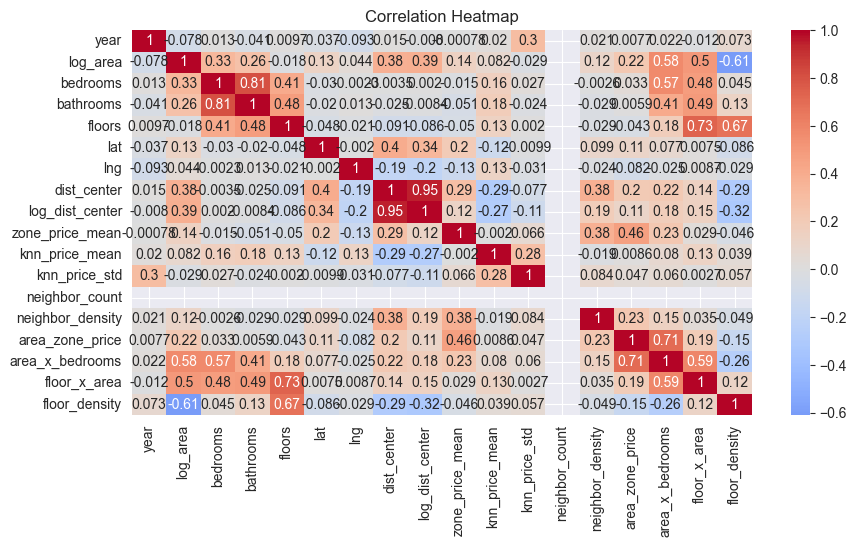

price               1.000000
zone_price_mean     0.134824
neighbor_density    0.052608
knn_price_mean      0.046000
log_area            0.045147
dist_center         0.040560
floor_x_area        0.038373
year                0.037207
area_x_bedrooms     0.036242
bedrooms            0.033670
knn_price_std       0.026050
bathrooms           0.024218
log_dist_center     0.020740
lat                 0.020532
area_zone_price     0.017932
floors              0.010688
lng                -0.019705
floor_density      -0.024418
neighbor_count           NaN
Name: price, dtype: float64

Correlation with target:
price               1.000000
zone_price_mean     0.134824
neighbor_density    0.052608
knn_price_mean      0.046000
log_area            0.045147
dist_center         0.040560
floor_x_area        0.038373
year                0.037207
area_x_bedrooms     0.036242
bedrooms            0.033670
knn_price_std       0.026050
bathrooms           0.024218
log_dist_center     0.020740
lat               

In [10]:


plt.figure(figsize=(10, 5))
df_test = build_features(pd.read_csv(get_data_path("final_data.csv")), mode="train")
sns.heatmap(
    df_test[NUM_FEATURES].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

# Correlation with target
corr_with_target = df_test[NUM_FEATURES + ["price"]].corr()["price"].sort_values(ascending=False)
print(corr_with_target)
print("\nCorrelation with target:")
print(corr_with_target)


**7. Hyperparameter Tuning**

In [ ]:
model_tuning = LGBMRegressor(
    random_state=42
)
pipe = Pipeline([
    ("prep", build_preprocessor()),
    ("clean_names", FeatureNameCleaner()),
    ("model", model)
])

In [ ]:
param_grid = {
    "model__learning_rate": [0.01, 0.03, 0.05],
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [-1, 5, 8],
    "model__num_leaves": [31, 63, 127],
    "model__min_child_samples": [20, 50, 100],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [0, 0.1, 1],
}

In [ ]:
grid = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid,
    n_iter=30,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [ ]:
grid.fit(X_train, y_train)

In [ ]:
print("\n=== TUNED LGBM (CV) ===")
print("Best CV RMSE:", -grid.best_score_)
print("Best params:", grid.best_params_)